In [2]:
import matplotlib.pyplot as plt
import numpy as np

In [10]:
data_dir = "/home/student/s/ssahu/share/aigm-classifier/data"
specs = np.load(f"{data_dir}/processed/intermediate_activations_conv6_specs.npy", allow_pickle=True)

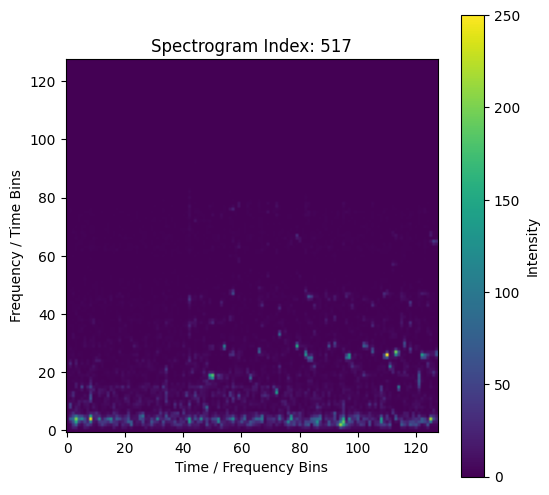

In [21]:
# Choose an index to view (e.g., the first one)
sample_idx = 517

plt.figure(figsize=(6, 6))
# cmap='viridis' or 'magma' work great for spectrograms
plt.imshow(specs[sample_idx], cmap='viridis', origin='lower')
plt.title(f"Spectrogram Index: {sample_idx}")
plt.colorbar(label='Intensity')
plt.xlabel("Time / Frequency Bins")
plt.ylabel("Frequency / Time Bins")
plt.show()

In [26]:
# Compare MEMMAP vs NON-MEMMAP spectrogram storing using REAL data from trainset
import os
import tempfile
import shutil
import csv
import librosa
from pathlib import Path
from scipy.ndimage import zoom

print("=" * 80)
print("COMPARING MEMMAP vs NON-MEMMAP SPECTROGRAM STORAGE (Real Data)")
print("=" * 80)

# Load manifest and extract filepaths + labels
manifest_path = "/home/student/s/ssahu/share/aigm-classifier/data/trainset/manifest.csv"
print(f"\n📂 Loading manifest from: {manifest_path}")

manifest_data = []
with open(manifest_path, 'r') as f:
    reader = csv.DictReader(f)
    for row in reader:
        manifest_data.append(row)

print(f"   ✓ Found {len(manifest_data)} samples in manifest")

# Use first 50 samples for comparison test
n_samples = min(50, len(manifest_data))
manifest_data = manifest_data[:n_samples]
print(f"   ✓ Using {n_samples} samples for comparison")

# Generate spectrograms from actual audio files
print(f"\n🎵 Generating spectrograms from audio files...")
specs_data = []
labels_data = []
failed_count = 0

for idx, sample_info in enumerate(manifest_data):
    filepath = sample_info.get('filepath')
    label = int(sample_info.get('label', 0))
    
    if not os.path.exists(filepath):
        print(f"   ⚠️  File not found: {filepath}")
        failed_count += 1
        continue
    
    try:
        # Load audio
        audio, sr = librosa.load(filepath, sr=44100, mono=True)
        
        # Compute mel spectrogram
        spec = librosa.feature.melspectrogram(y=audio, sr=44100, n_mels=128)
        
        # Resize to (128, 128) - same as CNN preprocessing
        zoom_factors = (128 / spec.shape[0], 128 / spec.shape[1])
        spec_resized = zoom(spec, zoom_factors, order=1).astype(np.float32)
        
        specs_data.append(spec_resized)
        labels_data.append(label)
        
        if (idx + 1) % 10 == 0:
            print(f"   ✓ Processed {idx + 1}/{n_samples} samples")
    
    except Exception as e:
        print(f"   ❌ Error loading {filepath}: {str(e)}")
        failed_count += 1
        continue

specs_data = np.array(specs_data, dtype=np.float32)
labels_data = np.array(labels_data, dtype=np.int32)

print(f"\n✓ Generated {len(specs_data)} spectrograms successfully")
print(f"  Failed: {failed_count}")
print(f"📊 Specs shape: {specs_data.shape}")
print(f"📊 Labels shape: {labels_data.shape}")

# Create temporary directories for testing
temp_dir = tempfile.mkdtemp()
memmap_dir = os.path.join(temp_dir, "memmap_test")
nonmemmap_dir = os.path.join(temp_dir, "nonmemmap_test")
os.makedirs(memmap_dir)
os.makedirs(nonmemmap_dir)

print(f"\n📁 Test directories created in {temp_dir}")

# ============================================================================
# METHOD 1: MEMMAP (Current approach in evaluate.py)
# ============================================================================
print("\n" + "-" * 80)
print("METHOD 1: MEMMAP STORAGE (evaluate.py approach)")
print("-" * 80)

memmap_specs_path = os.path.join(memmap_dir, "specs_memmap.npy")
memmap_labels_path = os.path.join(memmap_dir, "labels_memmap.npy")

# Pre-allocate memmap files
print("\n1️⃣  Pre-allocating memmap arrays...")
memmap_specs = np.memmap(memmap_specs_path, dtype=np.float32, mode='w+', 
                         shape=(len(specs_data), 128, 128))
memmap_labels = np.memmap(memmap_labels_path, dtype=np.int32, mode='w+', 
                          shape=(len(labels_data),))

# Write data incrementally (simulating evaluate.py's loop)
print("2️⃣  Writing data incrementally to memmap...")
processed_count = 0
for i in range(len(specs_data)):
    memmap_specs[i] = specs_data[i]
    memmap_labels[i] = labels_data[i]
    processed_count += 1
    
    # Flush every 10 samples (simulate evaluate.py's periodic flush)
    if (i + 1) % 10 == 0:
        memmap_specs.flush()
        memmap_labels.flush()

# Final flush
memmap_specs.flush()
memmap_labels.flush()

# Trim to actual processed count and save as proper numpy files
print("3️⃣  Trimming to processed count and saving as numpy files...")
specs_trimmed_memmap = np.array(memmap_specs[:processed_count])
labels_trimmed_memmap = np.array(memmap_labels[:processed_count])

np.save(memmap_specs_path.replace('.npy', '_final.npy'), specs_trimmed_memmap)
np.save(memmap_labels_path.replace('.npy', '_final.npy'), labels_trimmed_memmap)

del memmap_specs, memmap_labels

memmap_specs_final = np.load(os.path.join(memmap_dir, "specs_memmap_final.npy"))
memmap_labels_final = np.load(os.path.join(memmap_dir, "labels_memmap_final.npy"))

print(f"   ✓ Final specs shape: {memmap_specs_final.shape}")
print(f"   ✓ Final labels shape: {memmap_labels_final.shape}")

# ============================================================================
# METHOD 2: NON-MEMMAP (Direct numpy.save)
# ============================================================================
print("\n" + "-" * 80)
print("METHOD 2: NON-MEMMAP STORAGE (Direct numpy.save)")
print("-" * 80)

nonmemmap_specs_path = os.path.join(nonmemmap_dir, "specs_nonmemmap_final.npy")
nonmemmap_labels_path = os.path.join(nonmemmap_dir, "labels_nonmemmap_final.npy")

print("\n1️⃣  Saving directly with numpy.save...")
np.save(nonmemmap_specs_path, specs_data)
np.save(nonmemmap_labels_path, labels_data)
print("   ✓ Saved specs and labels directly")

nonmemmap_specs_final = np.load(nonmemmap_specs_path)
nonmemmap_labels_final = np.load(nonmemmap_labels_path)

print(f"   ✓ Loaded specs shape: {nonmemmap_specs_final.shape}")
print(f"   ✓ Loaded labels shape: {nonmemmap_labels_final.shape}")

# ============================================================================
# COMPARISON
# ============================================================================
print("\n" + "=" * 80)
print("COMPARISON RESULTS")
print("=" * 80)

# Shape comparison
print(f"\n🔍 Shape Comparison:")
print(f"   Memmap specs:     {memmap_specs_final.shape}")
print(f"   Non-memmap specs: {nonmemmap_specs_final.shape}")
if memmap_specs_final.shape == nonmemmap_specs_final.shape:
    print(f"   ✅ Shapes match")
else:
    print(f"   ❌ Shapes don't match!")

# Dtype comparison
print(f"\n🔍 Dtype Comparison:")
print(f"   Memmap specs:     {memmap_specs_final.dtype}")
print(f"   Non-memmap specs: {nonmemmap_specs_final.dtype}")
if memmap_specs_final.dtype == nonmemmap_specs_final.dtype:
    print(f"   ✅ Dtypes match")
else:
    print(f"   ❌ Dtypes don't match!")

# Value comparison
print(f"\n🔍 Value Comparison:")
diff = np.abs(memmap_specs_final - nonmemmap_specs_final)
max_diff = np.max(diff)
mean_diff = np.mean(diff)
print(f"   Max difference:  {max_diff:.2e}")
print(f"   Mean difference: {mean_diff:.2e}")
print(f"   % elements different (>1e-7): {100 * np.sum(diff > 1e-7) / diff.size:.4f}%")

if max_diff < 1e-6:
    print(f"   ✅ Values match (numerically identical)")
else:
    print(f"   ⚠️  Minor numerical differences detected")

# File size comparison
print(f"\n🔍 File Size Comparison:")
memmap_size = os.path.getsize(os.path.join(memmap_dir, "specs_memmap_final.npy")) / (1024**2)
nonmemmap_size = os.path.getsize(nonmemmap_specs_path) / (1024**2)
print(f"   Memmap file:     {memmap_size:.4f} MB")
print(f"   Non-memmap file: {nonmemmap_size:.4f} MB")

# Statistical comparison
print(f"\n🔍 Statistical Comparison (Specs):")
print(f"   {'Metric':<20} {'Memmap':<15} {'Non-memmap':<15} {'Match'}")
print(f"   {'-'*60}")
for metric_name, metric_fn in [('Min', np.min), ('Max', np.max), ('Mean', np.mean), ('Std', np.std)]:
    val_memmap = metric_fn(memmap_specs_final)
    val_nonmemmap = metric_fn(nonmemmap_specs_final)
    match = "✅" if np.allclose(val_memmap, val_nonmemmap) else "❌"
    print(f"   {metric_name:<20} {val_memmap:<15.6f} {val_nonmemmap:<15.6f} {match}")

print("\n" + "=" * 80)
print("CONCLUSION:")
print("=" * 80)
if (memmap_specs_final.shape == nonmemmap_specs_final.shape and 
    memmap_specs_final.dtype == nonmemmap_specs_final.dtype and 
    max_diff < 1e-6):
    print("✅ Both storage methods produce IDENTICAL results")
    print("   → Memmap method is safe and does not introduce data corruption")
else:
    print("⚠️  Some differences detected between methods")

# Cleanup
print(f"\n🧹 Cleaning up temporary directories...")
shutil.rmtree(temp_dir)
print("   ✓ Done")


COMPARING MEMMAP vs NON-MEMMAP SPECTROGRAM STORAGE (Real Data)

📂 Loading manifest from: /home/student/s/ssahu/share/aigm-classifier/data/trainset/manifest.csv
   ✓ Found 1000 samples in manifest
   ✓ Using 50 samples for comparison

🎵 Generating spectrograms from audio files...
   ✓ Processed 10/50 samples
   ✓ Processed 20/50 samples
   ✓ Processed 30/50 samples
   ✓ Processed 40/50 samples
   ✓ Processed 50/50 samples

✓ Generated 50 spectrograms successfully
  Failed: 0
📊 Specs shape: (50, 128, 128)
📊 Labels shape: (50,)

📁 Test directories created in /home/student/s/ssahu/share/aigm-classifier/.tmp/tmpn8g3ryeb

--------------------------------------------------------------------------------
METHOD 1: MEMMAP STORAGE (evaluate.py approach)
--------------------------------------------------------------------------------

1️⃣  Pre-allocating memmap arrays...
2️⃣  Writing data incrementally to memmap...
3️⃣  Trimming to processed count and saving as numpy files...
   ✓ Final specs shap


VISUAL COMPARISON: Sample Spectrograms


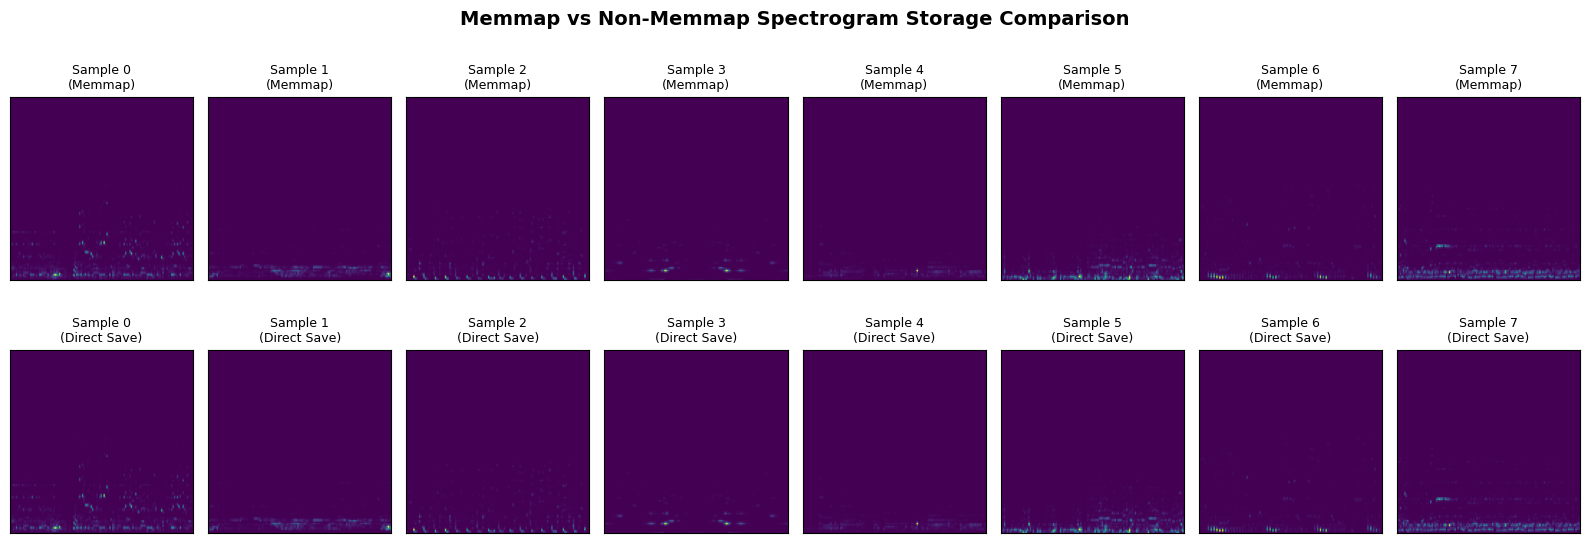


🔍 Absolute Difference Heatmaps (if any differences exist):


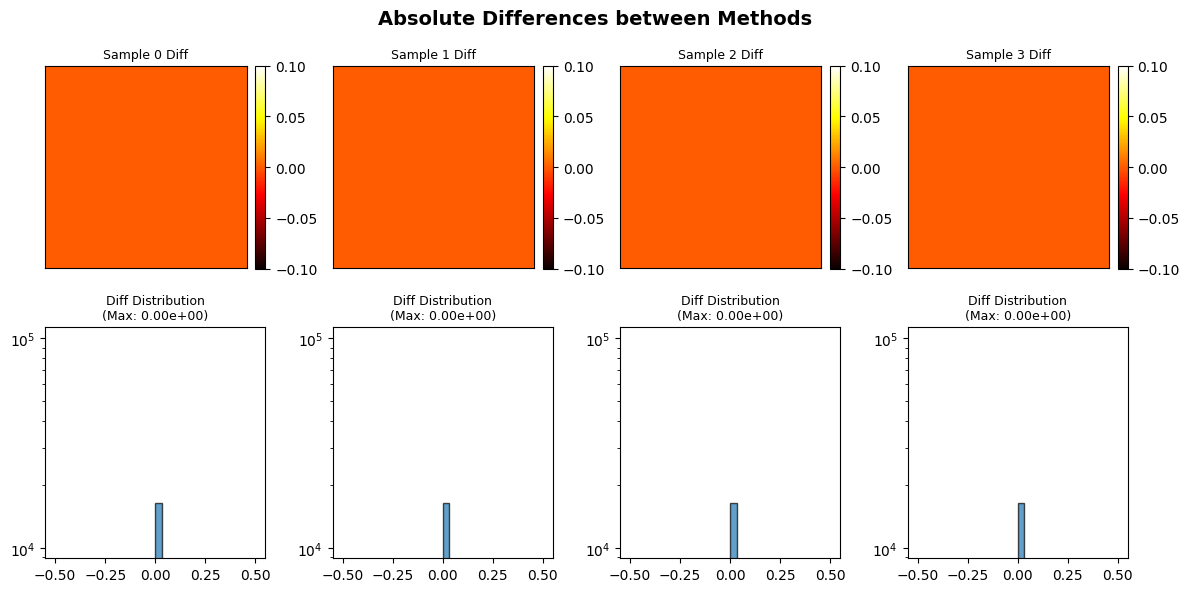


✅ Visualization complete!


In [27]:
# Visualize both memmap and non-memmap spectrograms side by side
print("\n" + "=" * 80)
print("VISUAL COMPARISON: Sample Spectrograms")
print("=" * 80)

# Show first 8 samples from each method
n_display = 8
fig, axes = plt.subplots(2, n_display, figsize=(16, 6))

for idx in range(n_display):
    # Memmap method (top row)
    ax1 = axes[0, idx]
    im1 = ax1.imshow(memmap_specs_final[idx], cmap='viridis', origin='lower')
    ax1.set_title(f'Sample {idx}\n(Memmap)', fontsize=9)
    ax1.set_xticks([])
    ax1.set_yticks([])
    
    # Non-memmap method (bottom row)
    ax2 = axes[1, idx]
    im2 = ax2.imshow(nonmemmap_specs_final[idx], cmap='viridis', origin='lower')
    ax2.set_title(f'Sample {idx}\n(Direct Save)', fontsize=9)
    ax2.set_xticks([])
    ax2.set_yticks([])

plt.suptitle('Memmap vs Non-Memmap Spectrogram Storage Comparison', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Display difference heatmaps
print("\n🔍 Absolute Difference Heatmaps (if any differences exist):")
fig, axes = plt.subplots(2, 4, figsize=(12, 6))

for idx in range(4):
    diff = np.abs(memmap_specs_final[idx] - nonmemmap_specs_final[idx])
    
    # Difference heatmap
    ax1 = axes[0, idx]
    im1 = ax1.imshow(diff, cmap='hot', origin='lower')
    ax1.set_title(f'Sample {idx} Diff', fontsize=9)
    ax1.set_xticks([])
    ax1.set_yticks([])
    plt.colorbar(im1, ax=ax1, fraction=0.046, pad=0.04)
    
    # Distribution of differences
    ax2 = axes[1, idx]
    ax2.hist(diff.flatten(), bins=30, edgecolor='black', alpha=0.7)
    ax2.set_title(f'Diff Distribution\n(Max: {np.max(diff):.2e})', fontsize=9)
    ax2.set_yscale('log')

plt.suptitle('Absolute Differences between Methods', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ Visualization complete!")


DIAGNOSTIC: Preprocessing Steps Analysis

Testing with audio file: /share/users/student/s/ssahu/aigm-classifier/data/trainset/real/fma_real/fma_medium/098/098301.mp3
File exists: True

1️⃣ Audio Loading:
   Audio shape: (1321967,)
   Sample rate: 44100
   Audio min: -0.562361, max: 0.903630, mean: -0.000021

2️⃣ Raw Mel Spectrogram (Power values):
   Shape: (128, 2582)
   Min: 0.000000, Max: 548.438477, Mean: 2.131660
   ⚠️ Very small values! This is why specs appear blank.

3️⃣ Convert to dB Scale (Recommended):
   Shape: (128, 2582)
   Min: -80.000000, Max: 0.000000, Mean: -43.966488
   ✅ Much better dynamic range!

4️⃣ Normalize to [0, 1]:
   Min: 0.000000, Max: 1.000000, Mean: 0.450419

5️⃣ Zoom to 128x128:
   Shape: (128, 128)
   Min: 0.000000, Max: 0.971336, Mean: 0.450761

VISUALIZATION COMPARISON


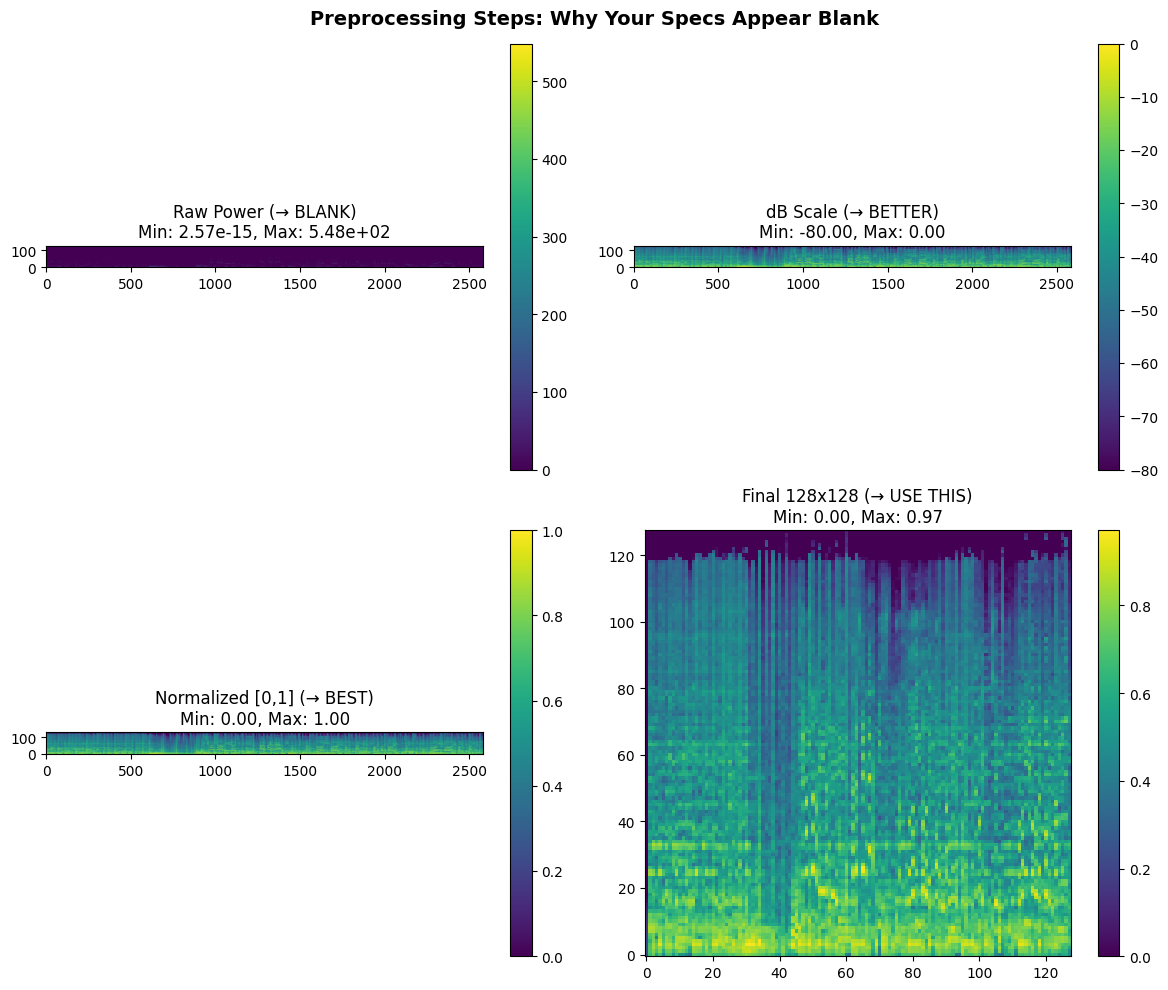


✅ SOLUTION: Add log-scaling to your preprocessing!
   Current: spec = librosa.feature.melspectrogram(...)
   ❌ Missing: spec = librosa.power_to_db(spec, ref=np.max)


In [28]:
# Diagnostic: Check preprocessing steps
print("=" * 80)
print("DIAGNOSTIC: Preprocessing Steps Analysis")
print("=" * 80)

# Load a single audio file from manifest
sample_path = manifest_data[0]['filepath']
print(f"\nTesting with audio file: {sample_path}")
print(f"File exists: {os.path.exists(sample_path)}")

# Step 1: Load audio
print("\n1️⃣ Audio Loading:")
audio, sr = librosa.load(sample_path, sr=44100, mono=True)
print(f"   Audio shape: {audio.shape}")
print(f"   Sample rate: {sr}")
print(f"   Audio min: {np.min(audio):.6f}, max: {np.max(audio):.6f}, mean: {np.mean(audio):.6f}")

# Step 2: Compute mel spectrogram (raw power)
print("\n2️⃣ Raw Mel Spectrogram (Power values):")
spec_power = librosa.feature.melspectrogram(y=audio, sr=44100, n_mels=128)
print(f"   Shape: {spec_power.shape}")
print(f"   Min: {np.min(spec_power):.6f}, Max: {np.max(spec_power):.6f}, Mean: {np.mean(spec_power):.6f}")
print(f"   ⚠️ Very small values! This is why specs appear blank.")

# Step 3: Convert to dB scale (RECOMMENDED)
print("\n3️⃣ Convert to dB Scale (Recommended):")
spec_db = librosa.power_to_db(spec_power, ref=np.max)
print(f"   Shape: {spec_db.shape}")
print(f"   Min: {np.min(spec_db):.6f}, Max: {np.max(spec_db):.6f}, Mean: {np.mean(spec_db):.6f}")
print(f"   ✅ Much better dynamic range!")

# Step 4: Normalize to [0, 1]
print("\n4️⃣ Normalize to [0, 1]:")
spec_normalized = (spec_db - np.min(spec_db)) / (np.max(spec_db) - np.min(spec_db) + 1e-7)
print(f"   Min: {np.min(spec_normalized):.6f}, Max: {np.max(spec_normalized):.6f}, Mean: {np.mean(spec_normalized):.6f}")

# Step 5: Zoom to 128x128
print("\n5️⃣ Zoom to 128x128:")
zoom_factors = (128 / spec_normalized.shape[0], 128 / spec_normalized.shape[1])
spec_resized = zoom(spec_normalized, zoom_factors, order=1).astype(np.float32)
print(f"   Shape: {spec_resized.shape}")
print(f"   Min: {np.min(spec_resized):.6f}, Max: {np.max(spec_resized):.6f}, Mean: {np.mean(spec_resized):.6f}")

# Visualization comparison
print("\n" + "=" * 80)
print("VISUALIZATION COMPARISON")
print("=" * 80)

fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# Raw power (blank)
im1 = axes[0, 0].imshow(spec_power, cmap='viridis', origin='lower')
axes[0, 0].set_title('Raw Power (→ BLANK)\nMin: {:.2e}, Max: {:.2e}'.format(np.min(spec_power), np.max(spec_power)))
plt.colorbar(im1, ax=axes[0, 0])

# dB scale
im2 = axes[0, 1].imshow(spec_db, cmap='viridis', origin='lower')
axes[0, 1].set_title('dB Scale (→ BETTER)\nMin: {:.2f}, Max: {:.2f}'.format(np.min(spec_db), np.max(spec_db)))
plt.colorbar(im2, ax=axes[0, 1])

# Normalized
im3 = axes[1, 0].imshow(spec_normalized, cmap='viridis', origin='lower')
axes[1, 0].set_title('Normalized [0,1] (→ BEST)\nMin: {:.2f}, Max: {:.2f}'.format(np.min(spec_normalized), np.max(spec_normalized)))
plt.colorbar(im3, ax=axes[1, 0])

# Final resized
im4 = axes[1, 1].imshow(spec_resized, cmap='viridis', origin='lower')
axes[1, 1].set_title('Final 128x128 (→ USE THIS)\nMin: {:.2f}, Max: {:.2f}'.format(np.min(spec_resized), np.max(spec_resized)))
plt.colorbar(im4, ax=axes[1, 1])

plt.suptitle('Preprocessing Steps: Why Your Specs Appear Blank', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print("\n✅ SOLUTION: Add log-scaling to your preprocessing!")
print("   Current: spec = librosa.feature.melspectrogram(...)")
print("   ❌ Missing: spec = librosa.power_to_db(spec, ref=np.max)")
